In [18]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [19]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [20]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_vehicules = []

for year in years:
    df_vehicules_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"vehicules-{year}.csv"), encoding="utf-8", sep = ";")
    df_vehicules.append(df_vehicules_year)

df_vehicules = pandas.concat(df_vehicules)
df_vehicules

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,201900000001,138 306 524,B01,2,7,0,2,5,23,1,NaN
1,201900000001,138 306 525,A01,2,17,1,0,3,11,1,NaN
2,201900000002,138 306 523,A01,1,7,4,0,1,0,1,NaN
3,201900000003,138 306 520,A01,1,7,0,2,1,2,1,NaN
4,201900000003,138 306 521,B01,1,7,1,0,4,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
92673,202400054401,155 686 119,Y01,1,60,1,2,7,0,5,NaN
92674,202400054401,155 686 120,A01,1,33,1,2,1,1,1,NaN
92675,202400054402,155 686 118,A01,1,10,0,2,1,2,1,NaN
92676,202400054402,155 686 121,B01,1,7,0,2,4,2,1,NaN


In [21]:
df_vehicules["id_vehicule"] = (
    df_vehicules["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [22]:
df_vehicules.replace(-1, pandas.NA, inplace=True)

for col in df_vehicules.columns:
    prop = df_vehicules[col].isna().sum() / len(df_vehicules)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For num_veh proportion missing: 0.00%
For senc proportion missing: 0.26%
For catv proportion missing: 0.00%
For obs proportion missing: 0.04%
For obsm proportion missing: 0.05%
For choc proportion missing: 0.05%
For manv proportion missing: 0.04%
For motor proportion missing: 0.22%
For occutc proportion missing: 99.13%


In [23]:
# First we are dropping features that we are not going to use: num_veh as we will use id_vehicule instead
df_vehicules.drop(columns = ['num_veh', 'occutc'], inplace = True)

In [24]:
# Removing rows with missing values

imputer_obs = SimpleImputer(strategy="most_frequent")
cat_small_na = df_vehicules.columns[(df_vehicules.isna().sum()>0) & (df_vehicules.isna().sum() < 5000)]
print(cat_small_na)
df_vehicules[cat_small_na]= df_vehicules[cat_small_na].replace({pandas.NA: np.nan})
df_vehicules[cat_small_na] = imputer_obs.fit_transform(df_vehicules[cat_small_na])


Index(['senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor'], dtype='str')


In [25]:
# And converting to int
cols_small_int = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor',"senc"]
df_vehicules[cols_small_int] = df_vehicules[cols_small_int].astype("int64")

In [26]:
categorical_features = cols_small_int[:]
numerical_features = []
features = categorical_features + numerical_features

In [27]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_vehicules_with_target = df_usagers[['Num_Acc', 'id_vehicule', 'grav_bin']].merge(
    df_vehicules,
    on=['Num_Acc', 'id_vehicule'],
    how='left'
)

target = "grav_bin"

In [28]:
df_vehicules_with_target.isna().sum()

Num_Acc        0
id_vehicule    0
grav_bin       0
senc           0
catv           0
obs            0
obsm           0
choc           0
manv           0
motor          0
dtype: int64

In [29]:
df_vehicules_with_target = df_vehicules_with_target.dropna()

In [30]:
df_vehicules_analyse = df_vehicules_with_target.copy() 

mapping = {
    0: "Undeterminable",
    1: "Bicycle",
    2: "Moped <50cc",
    3: "Microcar (enclosed motorized quadricycle)",
    4: "Unused reference since 2006 (registered scooter)",
    5: "Unused reference since 2006 (motorcycle)",
    6: "Unused reference since 2006 (sidecar)",
    7: "Passenger car only",
    8: "Unused reference since 2006 (car + caravan)",
    9: "Unused reference since 2006 (car + trailer)",
    10: "Light utility vehicle only 1.5T <= GVWR <= 3.5T with or without trailer",
    11: "Unused reference since 2006 (LUV (10) + caravan)",
    12: "Unused reference since 2006 (LUV (10) + trailer)",
    13: "Heavy goods vehicle only 3.5T < GVWR <= 7.5T",
    14: "Heavy goods vehicle only > 7.5T",
    15: "Heavy goods vehicle > 3.5T + trailer",
    16: "Road tractor only",
    17: "Road tractor + semi-trailer",
    18: "Unused reference since 2006 (public transport)",
    19: "Unused reference since 2006 (tramway)",
    20: "Special vehicle",
    21: "Agricultural tractor",
    30: "Scooter < 50cc",
    31: "Motorcycle > 50cc and <= 125cc",
    32: "Scooter > 50cc and <= 125cc",
    33: "Motorcycle > 125cc",
    34: "Scooter > 125cc",
    35: "Light quad <= 50cc (non-enclosed motorized quadricycle)",
    36: "Heavy quad > 50cc (non-enclosed motorized quadricycle)",
    37: "Bus",
    38: "Coach",
    39: "Train",
    40: "Tramway",
    41: "3-wheel motor vehicle <= 50cc",
    42: "3-wheel motor vehicle > 50cc <= 125cc",
    43: "3-wheel motor vehicle > 125cc",
    50: "Motorized personal transport device",
    60: "Non-motorized personal transport device",
    80: "Electric-assisted bicycle",
    99: "Other vehicle"
}

df_vehicules_analyse["catv"] = df_vehicules_analyse["catv"].replace(mapping)

mapping = {
    0: "Not applicable",
    1: "Parked vehicle",
    2: "Tree",
    3: "Metal guardrail",
    4: "Concrete guardrail",
    5: "Other guardrail",
    6: "Building, wall, bridge pier",
    7: "Vertical road sign support or emergency call post",
    8: "Pole",
    9: "Street furniture",
    10: "Parapet",
    11: "Island, refuge, bollard",
    12: "Curb",
    13: "Ditch, embankment, rock wall",
    14: "Other fixed obstacle on roadway",
    15: "Other fixed obstacle on sidewalk or shoulder",
    16: "Run-off-road without obstacle",
    17: "Culvert – culvert head"
}

df_vehicules_analyse["obs"] = df_vehicules_analyse["obs"].replace(mapping)

mapping = {
    0: "None",
    1: "Pedestrian",
    2: "Vehicle",
    4: "Rail vehicle",
    5: "Domestic animal",
    6: "Wild animal",
    9: "Other"
}

df_vehicules_analyse["obsm"] = df_vehicules_analyse["obsm"].replace(mapping)

mapping = {
    0: "None",
    1: "Front",
    2: "Front right",
    3: "Front left",
    4: "Rear",
    5: "Rear right",
    6: "Rear left",
    7: "Right side",
    8: "Left side",
    9: "Multiple impacts (rollovers)"
}

df_vehicules_analyse["choc"] = df_vehicules_analyse["choc"].replace(mapping)

mapping = {
    0: "Unknown",
    1: "No change of direction",
    2: "Same direction, same lane",
    3: "Between two lanes",
    4: "Reversing",
    5: "Wrong-way driving",
    6: "Crossing the central reservation",
    7: "In the bus lane, same direction",
    8: "In the bus lane, opposite direction",
    9: "Merging",
    10: "Making a U-turn on the roadway",
    11: "Left (changing lane)",
    12: "Right (changing lane)",
    13: "Left (swerving)",
    14: "Right (swerving)",
    15: "Left (turning)",
    16: "Right (turning)",
    17: "Left (overtaking)",
    18: "Right (overtaking)",
    19: "Crossing the roadway",
    20: "Parking maneuver",
    21: "Evasive maneuver",
    22: "Door opening",
    23: "Stopped (excluding parking)",
    24: "Parked (with occupants)",
    25: "Driving on sidewalk",
    26: "Other maneuvers"
}

df_vehicules_analyse["manv"] = df_vehicules_analyse["manv"].replace(mapping)

mapping = {
    0: "Unknown",
    1: "Hydrocarbons",
    2: "Hybrid electric",
    3: "Electric",
    4: "Hydrogen",
    5: "Human-powered",
    6: "Other"
}

df_vehicules_analyse["motor"] = df_vehicules_analyse["motor"].replace(mapping)

mapping = {
    0: "Unknown",
    1: "Increasing PK or PR or postal address number",
    2: "Decreasing PK or PR or postal address number",
    3: "No reference point"
}

df_vehicules_analyse["senc"] = df_vehicules_analyse["senc"].replace(mapping)

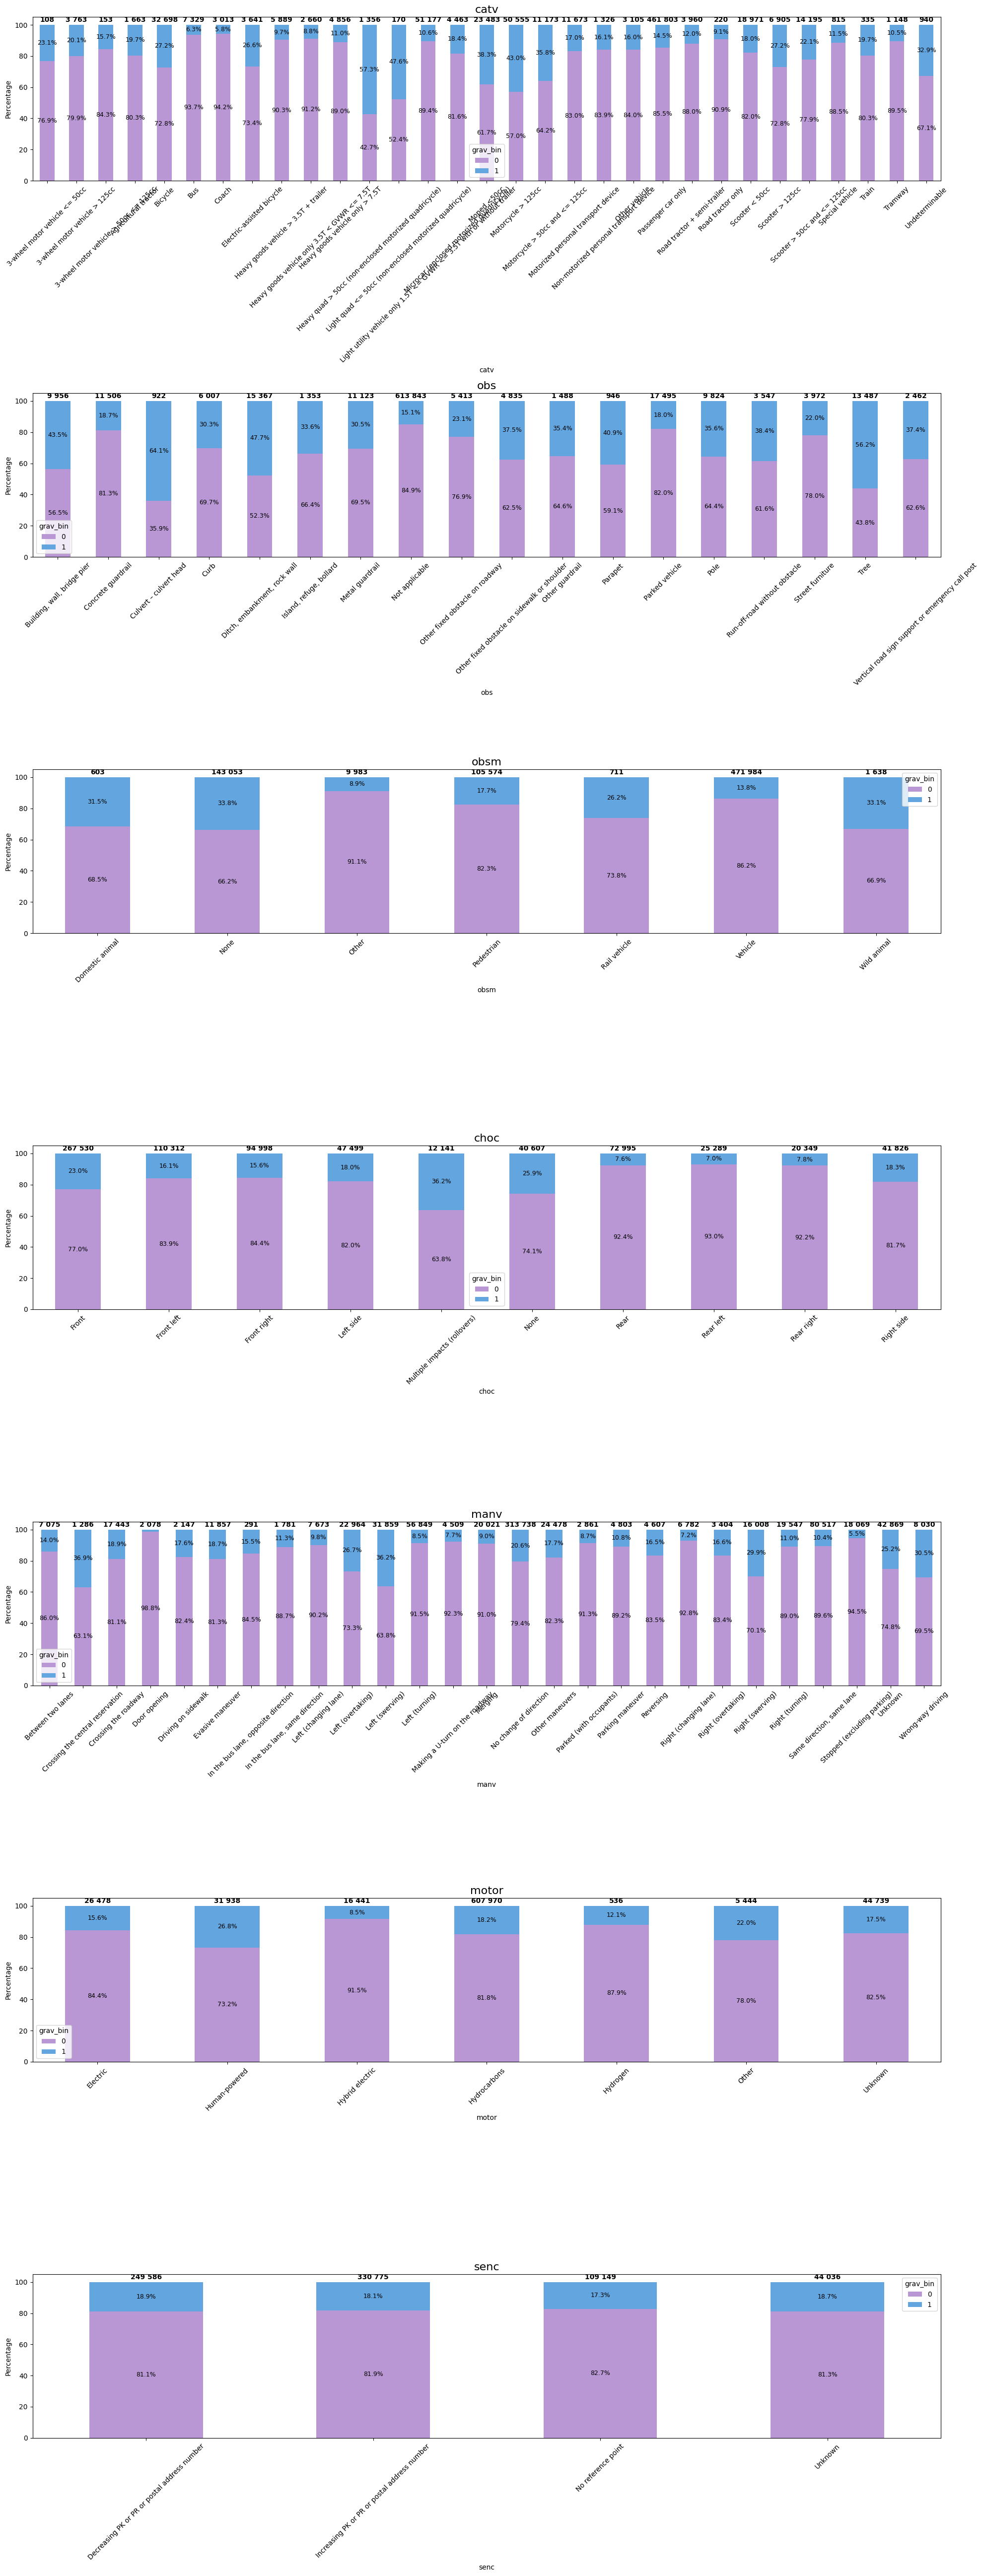

In [31]:
fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_vehicules_analyse[feature],
        df_vehicules_analyse[target],
        normalize="index"
    ) * 100

    counts = df_vehicules_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [1]:
def latex_escape_category(x):
    """
    Convert category labels into LaTeX-safe strings.
    """
    x = str(x)

    # Replace comparison operators with LaTeX math symbols
    x = x.replace("<=", r"$\le$")
    x = x.replace(">=", r"$\ge$")
    x = x.replace("<", r"$<$")
    x = x.replace(">", r"$>$")

    # Escape LaTeX special characters
    x = x.replace("&", r"\&")
    x = x.replace("%", r"\%")
    x = x.replace("_", r"\_")
    x = x.replace("#", r"\#")

    return x

output_lines = []

for feature in features:
    # Count per class
    counts = df_vehicules_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    
    # Proportions (in %)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    # Ensure column order (adapt if needed)
    # Assuming: 0 = not severe, 1 = severe
    for i, category in enumerate(counts.index):
        category_latex = latex_escape_category(category)

        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category_latex} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        # Replace commas for LaTeX formatting (French style spacing)
        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

# Print result
print("\n".join(output_lines))

NameError: name 'features' is not defined

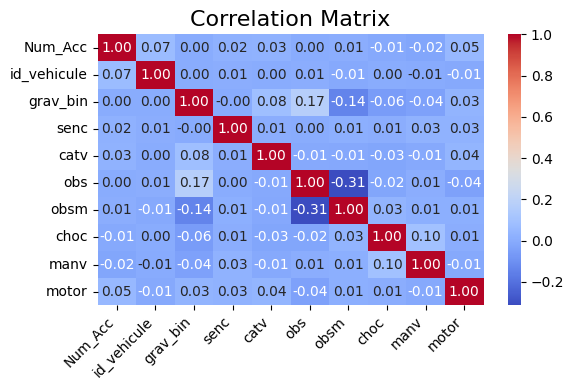

In [33]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    df_vehicules_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
X = df_vehicules_with_target[categorical_features + numerical_features]
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines_over = {}
pipelines_under = {}
pipelines_combine = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("over_sampling", RandomOverSampler(random_state=42)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("under_sampling", RandomUnderSampler(random_state=42)),
        ("model", model)
    ])
    pipelines_combine[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("combine_sampling", SMOTEENN(random_state=42)),
        ("model", model)
    ])

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_train, y_pred))

Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.3393385140257771
Recall: 0.6673997931092327
F1: 0.4499172276443961
Accuracy: 0.7015946533614161
              precision    recall  f1-score   support

           0       0.91      0.71      0.80    479533
           1       0.34      0.67      0.45    107303

    accuracy                           0.70    586836
   macro avg       0.62      0.69      0.62    586836
weighted avg       0.80      0.70      0.73    586836


 Decision Tree
Precision: 0.33771541775657793
Recall: 0.6545390156845569
F1: 0.4455468469982967
Accuracy: 0.7021263180854617
              precision    recall  f1-score   support

           0       0.90      0.71      0.80    479533
           1       0.34      0.65      0.45    107303

    accuracy                           0.70    586836
   macro avg       0.62      0.68      0.62    586836
weighted avg       0.80      0.70      0.73    586836


 Gradient Boosting
Precision: 0.34341894525596

In [36]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_val, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)
    
    print(classification_report(y_val, y_pred))

Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.3412162961910849
Recall: 0.6682119512308191
F1: 0.4517503995988341
Accuracy: 0.7066573966150679
              precision    recall  f1-score   support

           0       0.90      0.71      0.80     95797
           1       0.34      0.67      0.45     21571

    accuracy                           0.70    117368
   macro avg       0.62      0.69      0.62    117368
weighted avg       0.80      0.70      0.73    117368


 Decision Tree
Precision: 0.3892388021260156
Recall: 0.7706643178341291
F1: 0.5172370877411325
Accuracy: 0.7066573966150679
              precision    recall  f1-score   support

           0       0.93      0.73      0.82     95797
           1       0.39      0.77      0.52     21571

    accuracy                           0.74    117368
   macro avg       0.66      0.75      0.67    117368
weighted avg       0.83      0.74      0.76    117368


 Gradient Boosting
Precision: 0.346491016810365

In [37]:
# Finally we are going to save the dataset cleaned
df_vehicules.to_csv("df_vehicules_clean.csv", index=False)